# Hyperparameter Exploration: buffer_length, hidden_size, and num_layers

This notebook explores how the FiniteImpulseResponseModel's performance varies with different hyperparameter configurations:
- `buffer_length`: The number of input samples to use as context (affects input_size = buffer_length × num_channels)
- `hidden_size`: The size of the hidden layers
- `num_layers`: The number of hidden layers

We'll train models with different combinations of these hyperparameters and compare their performance.


In [1]:
import lyrebird
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
from collections import defaultdict
import pandas as pd


## Step 1: Load Audio Metadata

We'll load audio files to get metadata (channels, sample rate). 
- **Training data**: Piano files
- **Test data**: Organ files

Datasets with different buffer lengths will be created during exploration.


In [2]:
# Configuration
# Training data: Piano files
train_input_wav_path = "piano.wav"
train_output_wav_path = "piano with distortion.wav"

# Test data: Organ files
test_input_wav_path = "organ.wav"
test_output_wav_path = "organ with distortion.wav"

# Load audio to get metadata (we'll create datasets with different buffer_lengths later)
import torchaudio
train_input_waveform, train_input_sample_rate = torchaudio.load(train_input_wav_path)
train_output_waveform, train_output_sample_rate = torchaudio.load(train_output_wav_path)

test_input_waveform, test_input_sample_rate = torchaudio.load(test_input_wav_path)
test_output_waveform, test_output_sample_rate = torchaudio.load(test_output_wav_path)

# Verify sample rates match
if train_input_sample_rate != train_output_sample_rate:
    raise ValueError(f"Training sample rates must match: input={train_input_sample_rate}, output={train_output_sample_rate}")

if test_input_sample_rate != test_output_sample_rate:
    raise ValueError(f"Test sample rates must match: input={test_input_sample_rate}, output={test_output_sample_rate}")

if train_input_sample_rate != test_input_sample_rate:
    raise ValueError(f"Training and test sample rates must match: train={train_input_sample_rate}, test={test_input_sample_rate}")

num_channels, train_total_samples = train_input_waveform.shape
train_output_channels, _ = train_output_waveform.shape

test_num_channels, test_total_samples = test_input_waveform.shape
test_output_channels, _ = test_output_waveform.shape

# Verify channels match
if num_channels != test_num_channels:
    raise ValueError(f"Channels must match: train={num_channels}, test={test_num_channels}")

if train_output_channels != test_output_channels:
    raise ValueError(f"Output channels must match: train={train_output_channels}, test={test_output_channels}")

print(f"Training data (piano) metadata:")
print(f"  Sample rate: {train_input_sample_rate} Hz")
print(f"  Input channels: {num_channels}")
print(f"  Output channels: {train_output_channels}")
print(f"  Total samples: {train_total_samples}")

print(f"\nTest data (organ) metadata:")
print(f"  Sample rate: {test_input_sample_rate} Hz")
print(f"  Input channels: {test_num_channels}")
print(f"  Output channels: {test_output_channels}")
print(f"  Total samples: {test_total_samples}")

# We'll use a subset of training data for faster exploration
train_subset_size = min(500000, train_total_samples)
print(f"\nWill use subset: {train_subset_size} samples from training data for exploration")


Training data (piano) metadata:
  Sample rate: 44100 Hz
  Input channels: 1
  Output channels: 1
  Total samples: 4964810

Test data (organ) metadata:
  Sample rate: 44100 Hz
  Input channels: 1
  Output channels: 1
  Total samples: 4964810

Will use subset: 500000 samples from training data for exploration


/home/mfrancza/projects/lyrebird/venv/lib/python3.12/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


## Step 2: Define Hyperparameter Grid

We'll explore different combinations of:
- `buffer_length`: [128, 256, 512, 1024] - number of input samples for context
- `hidden_size`: [32, 64, 128, 256] - size of hidden layers
- `num_layers`: [1, 2, 3, 4, 5] - number of hidden layers

Note: `input_size = buffer_length × num_channels` will vary with `buffer_length` while keeping channels constant.


In [3]:
# Define hyperparameter ranges
buffer_lengths = [128, 256, 512, 1024]  # Different buffer lengths to explore
hidden_sizes = [32, 64, 128, 256]
num_layers_list = [1, 2, 3, 4, 5]

print(f"Hyperparameter ranges:")
print(f"  buffer_length: {buffer_lengths}")
print(f"  hidden_size: {hidden_sizes}")
print(f"  num_layers: {num_layers_list}")
print(f"\nTotal combinations: {len(buffer_lengths) * len(hidden_sizes) * len(num_layers_list)}")
print(f"  (This will explore all combinations)")


Hyperparameter ranges:
  buffer_length: [128, 256, 512, 1024]
  hidden_size: [32, 64, 128, 256]
  num_layers: [1, 2, 3, 4, 5]

Total combinations: 80
  (This will explore all combinations)


## Step 3: Training Function

Create a function to train and evaluate a model with specific hyperparameters.


In [4]:
def train_and_evaluate_model(input_size, hidden_size, num_layers, output_size, 
                             train_loader, val_loader, test_loader=None, epochs=3, device=None):
    """
    Train and evaluate a model with given hyperparameters.
    
    Args:
        test_loader: Optional test loader for evaluating on test set
    
    Returns:
        tuple: (results_dict, trained_model) where results_dict contains metrics
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Create model
    model = lyrebird.FiniteImpulseResponseModel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size
    ).to(device)
    
    # Count parameters
    num_params = sum(p.numel() for p in model.parameters())
    
    # Setup training
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Training loop
    train_losses = []
    val_losses = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Train
        model.train()
        epoch_train_loss = 0
        num_train_batches = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            epoch_train_loss += loss.item()
            num_train_batches += 1
        train_losses.append(epoch_train_loss / num_train_batches)
        
        # Validate
        model.eval()
        epoch_val_loss = 0
        num_val_batches = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = loss_fn(pred, y)
                epoch_val_loss += loss.item()
                num_val_batches += 1
        val_losses.append(epoch_val_loss / num_val_batches)
    
    training_time = time.time() - start_time
    
    # Evaluate on test set if provided
    test_loss = None
    if test_loader is not None:
        model.eval()
        test_loss_value = 0
        num_test_batches = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = loss_fn(pred, y)
                test_loss_value += loss.item()
                num_test_batches += 1
        test_loss = test_loss_value / num_test_batches
    
    results = {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'num_parameters': num_params,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'min_val_loss': min(val_losses),
        'training_time': training_time,
        'train_losses': train_losses,
        'val_losses': val_losses
    }
    
    if test_loss is not None:
        results['test_loss'] = test_loss
    
    return results, model


## Step 4: Run Hyperparameter Exploration

Train models with all combinations of hyperparameters. For each buffer_length, we'll create a new dataset.


In [5]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

from torch.utils.data import Subset
results = []
output_size = train_output_channels
batch_size = 32

total_combinations = len(buffer_lengths) * len(hidden_sizes) * len(num_layers_list)
current = 0

print("Starting hyperparameter exploration...")
print(f"Training data: {train_input_wav_path} -> {train_output_wav_path}")
print(f"Test data: {test_input_wav_path} -> {test_output_wav_path}\n")

for buffer_length in buffer_lengths:
    print(f"Creating datasets with buffer_length={buffer_length}...")
    
    # Create training dataset (piano) with this buffer length
    train_full_dataset = lyrebird.FiniteImpulseResponseDataSet(
        input_wav_path=train_input_wav_path,
        output_wav_path=train_output_wav_path,
        buffer_length=buffer_length
    )
    
    # Create test dataset (organ) with this buffer length
    test_full_dataset = lyrebird.FiniteImpulseResponseDataSet(
        input_wav_path=test_input_wav_path,
        output_wav_path=test_output_wav_path,
        buffer_length=buffer_length
    )
    
    # Use subset of training data for faster exploration
    actual_train_subset_size = min(train_subset_size, len(train_full_dataset))
    train_indices = torch.arange(actual_train_subset_size)
    train_dataset_subset = Subset(train_full_dataset, train_indices)
    
    # Split training dataset into train and validation (from piano)
    train_size = int(0.8 * len(train_dataset_subset))
    val_size = len(train_dataset_subset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        train_dataset_subset, [train_size, val_size], 
        generator=torch.Generator().manual_seed(42)
    )
    
    # Use full organ dataset as test set
    test_dataset = test_full_dataset
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                            num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                             num_workers=2, pin_memory=True)
    
    input_size = buffer_length * num_channels
    
    print(f"  Training dataset: {len(train_dataset)} samples (piano)")
    print(f"  Validation dataset: {len(val_dataset)} samples (piano)")
    print(f"  Test dataset: {len(test_dataset)} samples (organ)")
    print(f"  Input size: {input_size}")
    print(f"  Training on {len(hidden_sizes)} hidden_sizes × {len(num_layers_list)} num_layers combinations...\n")
    
    # Train models with different hidden_size and num_layers for this buffer_length
    for hidden_size in hidden_sizes:
        for num_layers in num_layers_list:
            current += 1
            print(f"[{current}/{total_combinations}] buffer_length={buffer_length}, hidden_size={hidden_size}, num_layers={num_layers}")
            
            # Train and evaluate on piano validation set, and test on organ
            result, trained_model = train_and_evaluate_model(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                output_size=output_size,
                train_loader=train_loader,
                val_loader=val_loader,  # Piano validation
                test_loader=test_loader,  # Organ test set
                epochs=3,
                device=device
            )
            
            # Add buffer_length to results
            result['buffer_length'] = buffer_length
            results.append(result)
            
            print(f"  Final train loss (piano): {result['final_train_loss']:.6f}")
            print(f"  Final val loss (piano): {result['final_val_loss']:.6f}")
            print(f"  Test loss (organ): {result['test_loss']:.6f}")
            print(f"  Parameters: {result['num_parameters']:,}")
            print(f"  Time: {result['training_time']:.2f}s\n")

print("Exploration complete!")


Using device: cuda

Starting hyperparameter exploration...
Training data: piano.wav -> piano with distortion.wav
Test data: organ.wav -> organ with distortion.wav

Creating datasets with buffer_length=128...


  Training dataset: 400000 samples (piano)
  Validation dataset: 100000 samples (piano)
  Test dataset: 4964682 samples (organ)
  Input size: 128
  Training on 4 hidden_sizes × 5 num_layers combinations...

[1/80] buffer_length=128, hidden_size=32, num_layers=1


  Final train loss (piano): 0.003151
  Final val loss (piano): 0.003145
  Test loss (organ): 0.000495
  Parameters: 4,161
  Time: 102.59s

[2/80] buffer_length=128, hidden_size=32, num_layers=2


  Final train loss (piano): 0.002741
  Final val loss (piano): 0.002666
  Test loss (organ): 0.000493
  Parameters: 5,217
  Time: 97.52s

[3/80] buffer_length=128, hidden_size=32, num_layers=3


  Final train loss (piano): 0.002644
  Final val loss (piano): 0.002571
  Test loss (organ): 0.000517
  Parameters: 6,273
  Time: 118.18s

[4/80] buffer_length=128, hidden_size=32, num_layers=4


...

  Final train loss (piano): 0.002767
  Final val loss (piano): 0.002707
  Test loss (organ): 0.000618
  Parameters: 262,657
  Time: 102.71s

[77/80] buffer_length=1024, hidden_size=256, num_layers=2


  Final train loss (piano): 0.001405
  Final val loss (piano): 0.001489
  Test loss (organ): 0.000718
  Parameters: 328,449
  Time: 113.86s

[78/80] buffer_length=1024, hidden_size=256, num_layers=3


  Final train loss (piano): 0.001227
  Final val loss (piano): 0.001188
  Test loss (organ): 0.000725
  Parameters: 394,241
  Time: 122.22s

[79/80] buffer_length=1024, hidden_size=256, num_layers=4


  Final train loss (piano): 0.001218
  Final val loss (piano): 0.001121
  Test loss (organ): 0.000699
  Parameters: 460,033
  Time: 128.89s

[80/80] buffer_length=1024, hidden_size=256, num_layers=5


  Final train loss (piano): 0.001215
  Final val loss (piano): 0.001178
  Test loss (organ): 0.000764
  Parameters: 525,825
  Time: 134.68s

Exploration complete!


## Step 5: Analyze Results

Create a DataFrame for easy analysis and find the best performing configurations.


In [6]:
# Create DataFrame from results
df = pd.DataFrame(results)

# Sort by test loss (organ) and validation loss (piano)
df_sorted_test = df.sort_values('test_loss')
df_sorted_val = df.sort_values('final_val_loss')

print("Results Summary (Top 20 configurations by test loss on organ):")
print("=" * 120)
print(df_sorted_test[['buffer_length', 'hidden_size', 'num_layers', 'input_size', 'num_parameters', 
                      'final_train_loss', 'final_val_loss', 'test_loss', 'training_time']].head(20).to_string(index=False))
print("\n" + "=" * 120)
print(f"\nBest configuration (lowest test loss on organ):")
best_test = df_sorted_test.iloc[0]
print(f"  buffer_length: {int(best_test['buffer_length'])}")
print(f"  input_size: {int(best_test['input_size'])} (buffer_length × {num_channels} channels)")
print(f"  hidden_size: {int(best_test['hidden_size'])}")
print(f"  num_layers: {int(best_test['num_layers'])}")
print(f"  num_parameters: {int(best_test['num_parameters']):,}")
print(f"  Final train loss (piano): {best_test['final_train_loss']:.6f}")
print(f"  Final val loss (piano): {best_test['final_val_loss']:.6f}")
print(f"  Test loss (organ): {best_test['test_loss']:.6f}")
print(f"  Min val loss (piano): {best_test['min_val_loss']:.6f}")
print(f"  Training time: {best_test['training_time']:.2f}s")

print(f"\n\nBest configuration (lowest validation loss on piano):")
best_val = df_sorted_val.iloc[0]
print(f"  buffer_length: {int(best_val['buffer_length'])}")
print(f"  input_size: {int(best_val['input_size'])} (buffer_length × {num_channels} channels)")
print(f"  hidden_size: {int(best_val['hidden_size'])}")
print(f"  num_layers: {int(best_val['num_layers'])}")
print(f"  num_parameters: {int(best_val['num_parameters']):,}")
print(f"  Final train loss (piano): {best_val['final_train_loss']:.6f}")
print(f"  Final val loss (piano): {best_val['final_val_loss']:.6f}")
print(f"  Test loss (organ): {best_val['test_loss']:.6f}")
print(f"  Min val loss (piano): {best_val['min_val_loss']:.6f}")
print(f"  Training time: {best_val['training_time']:.2f}s")


Results Summary (Top 20 configurations by test loss on organ):
 buffer_length  hidden_size  num_layers  input_size  num_parameters  final_train_loss  final_val_loss  test_loss  training_time
           128          128           1         128           16641          0.003069        0.002924   0.000465     116.987651
           128           64           1         128            8321          0.003089        0.002929   0.000474     117.398986
           128          256           1         128           33281          0.003071        0.002998   0.000481      97.863026
           128           32           2         128            5217          0.002741        0.002666   0.000493      97.521984
           256           32           2         256            9313          0.002412        0.002475   0.000494     105.169921
           128           32           1         128            4161          0.003151        0.003145   0.000495     102.588074
           256          128           1  

## Step 6: Visualize Results

Create visualizations to understand how hyperparameters affect model performance.


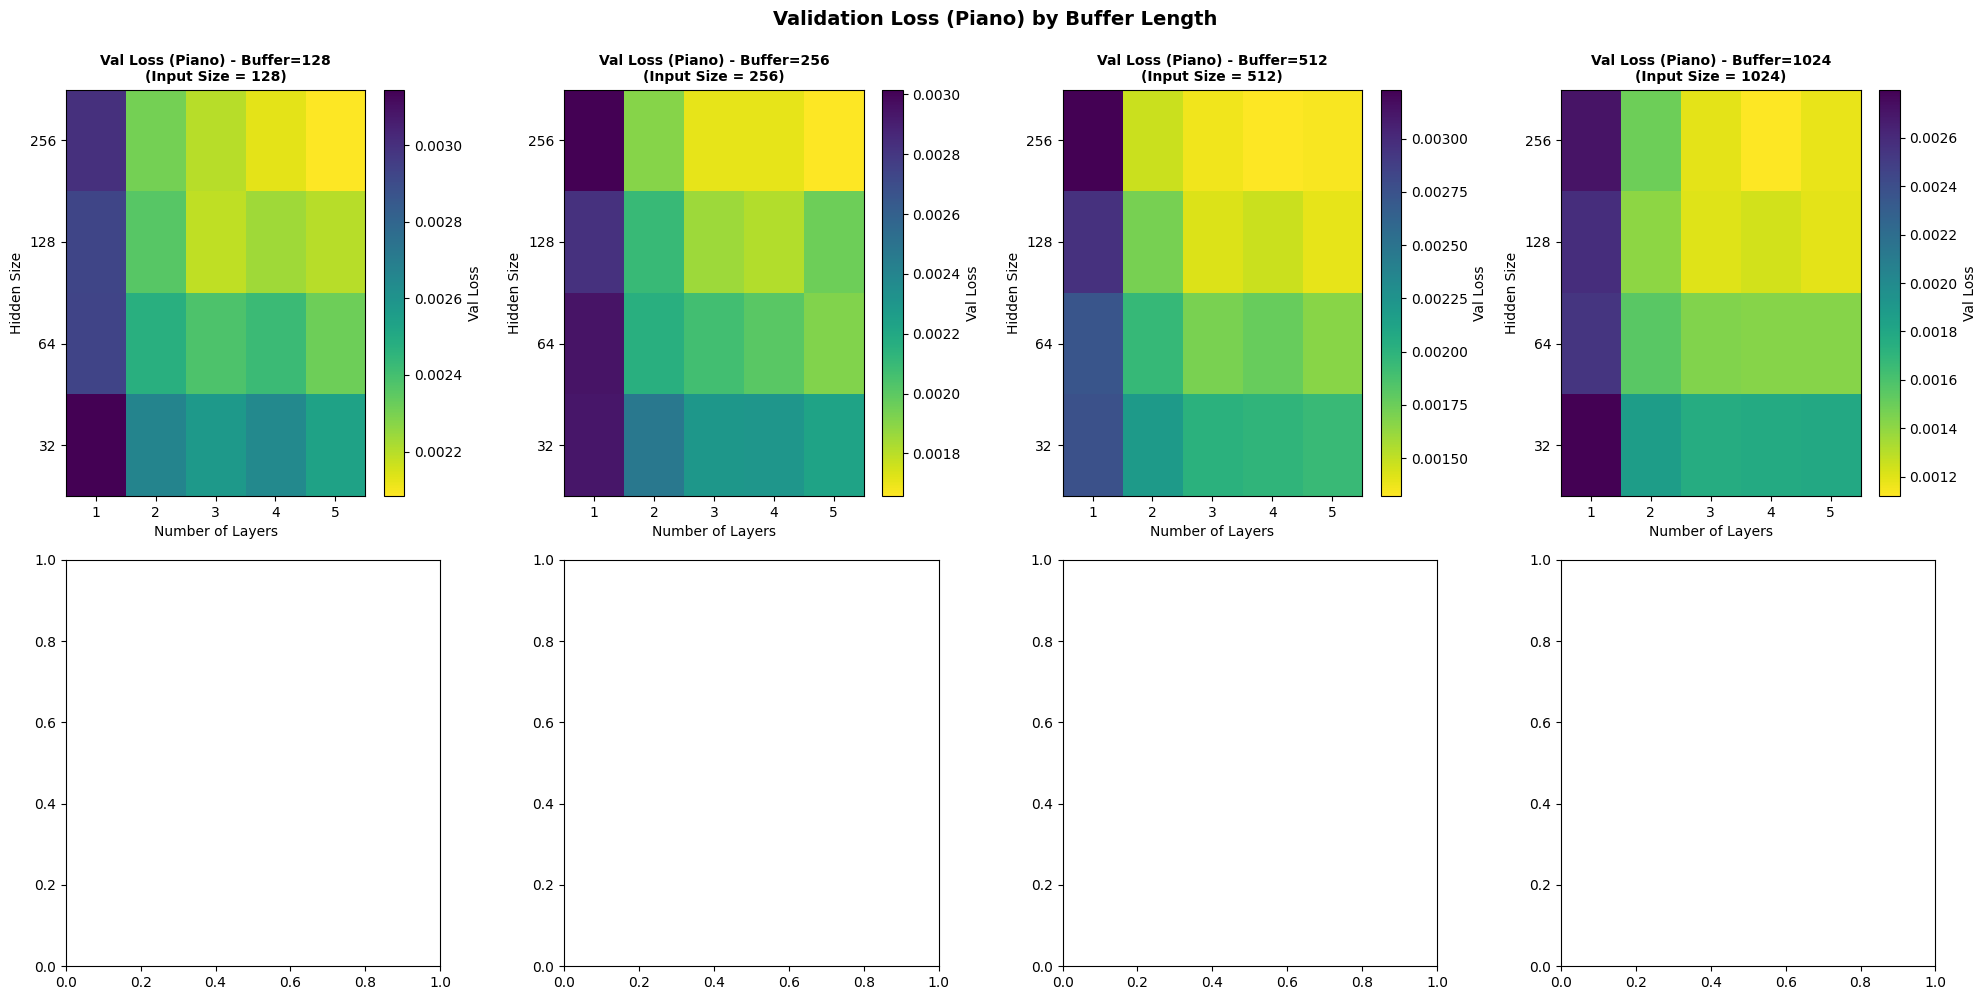

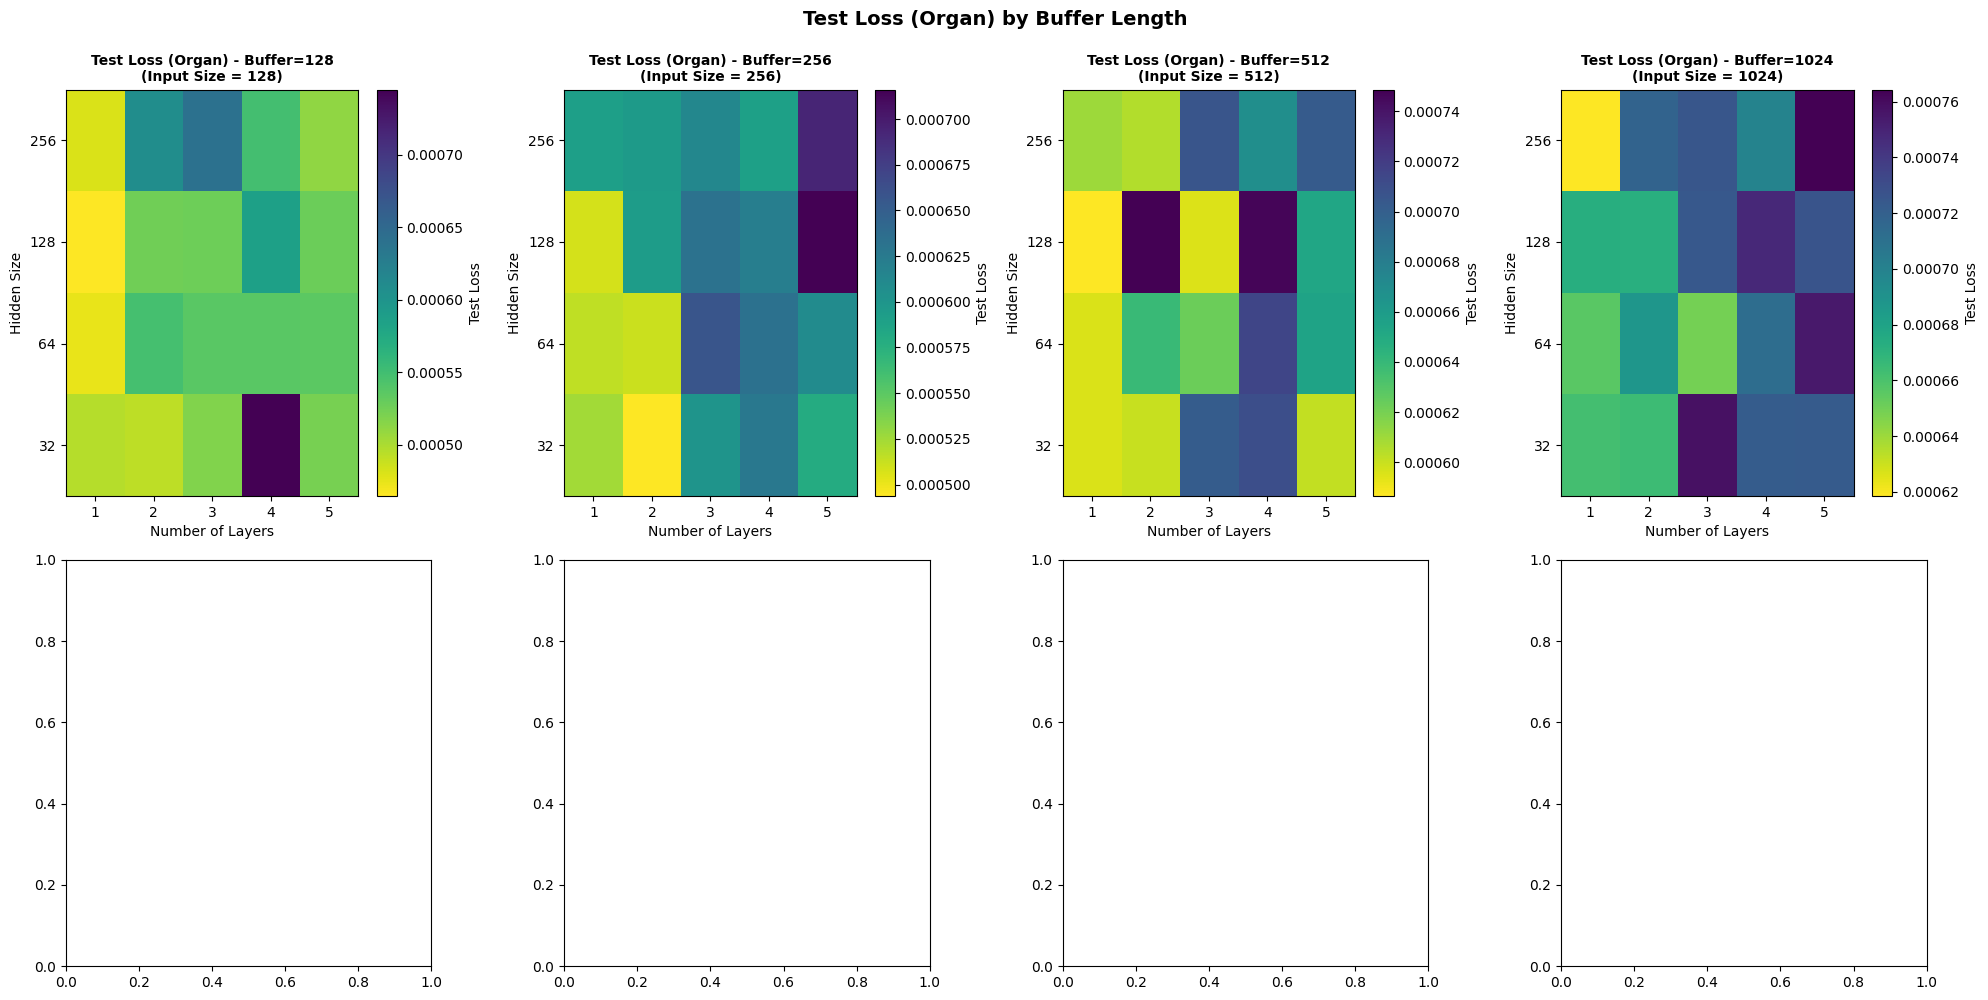

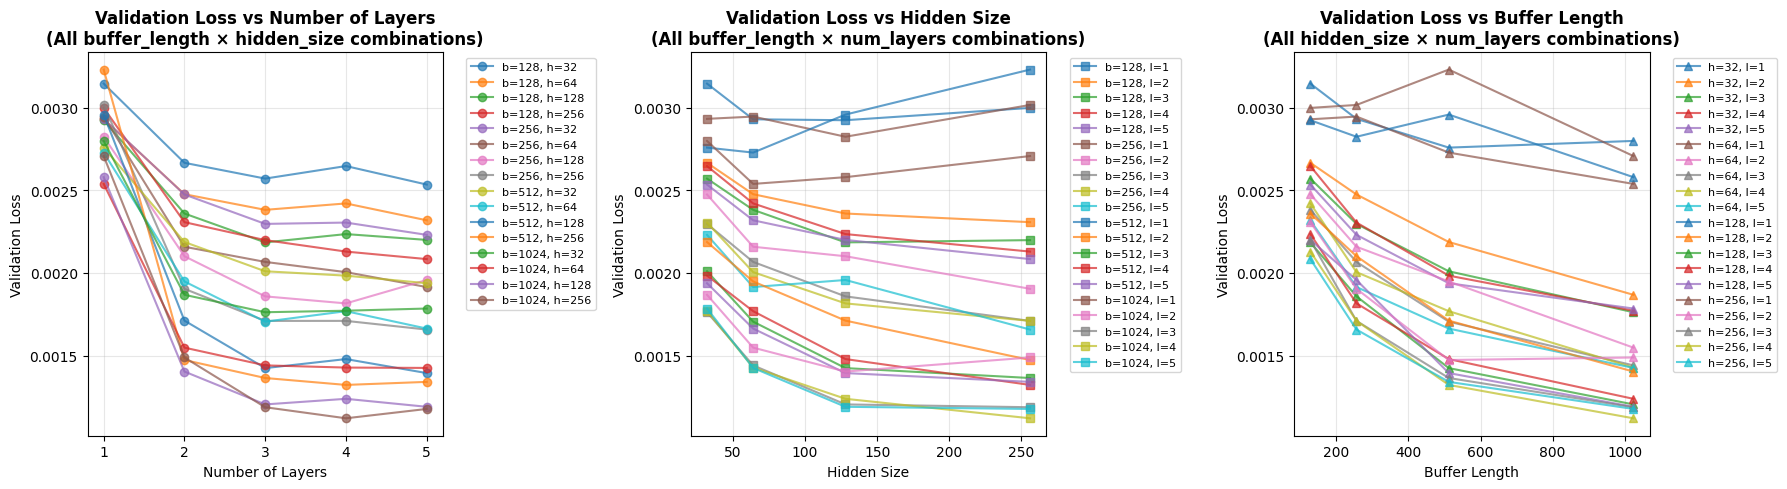

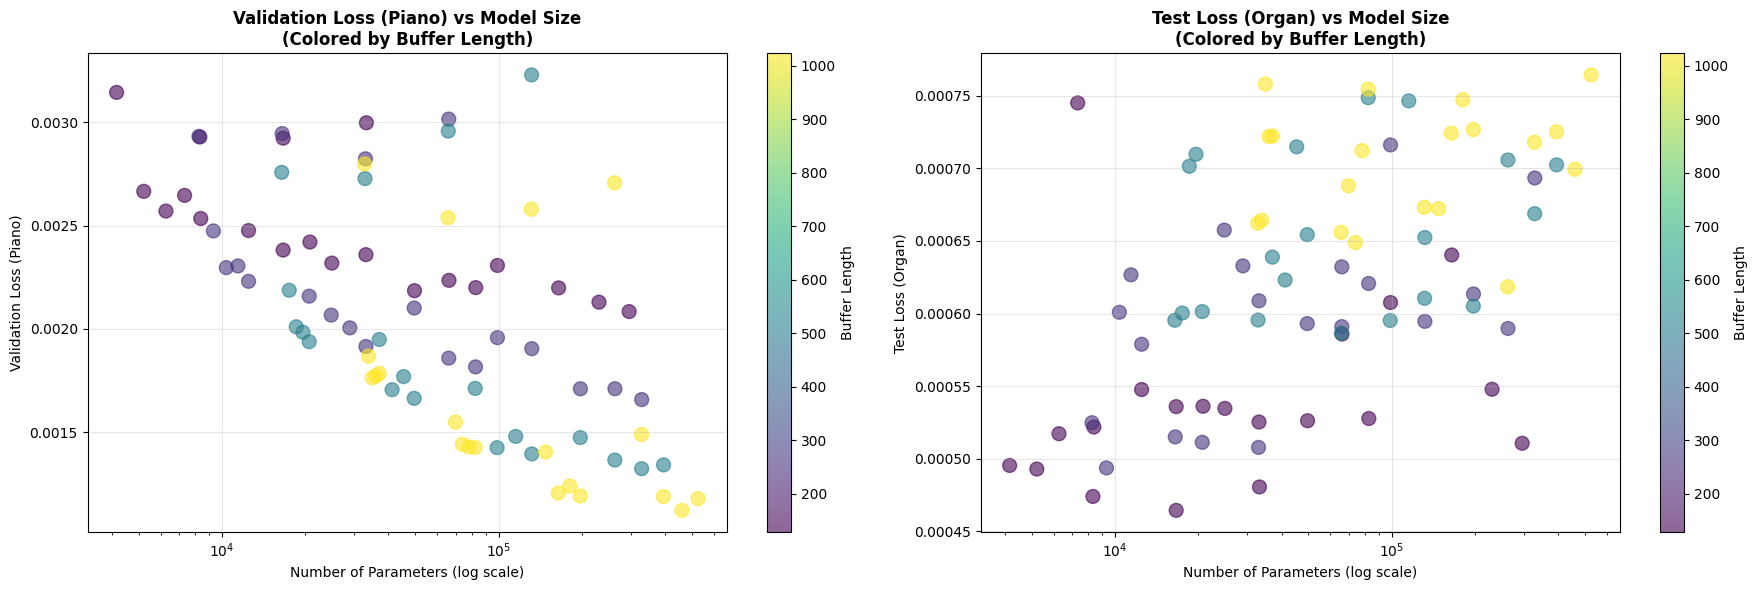

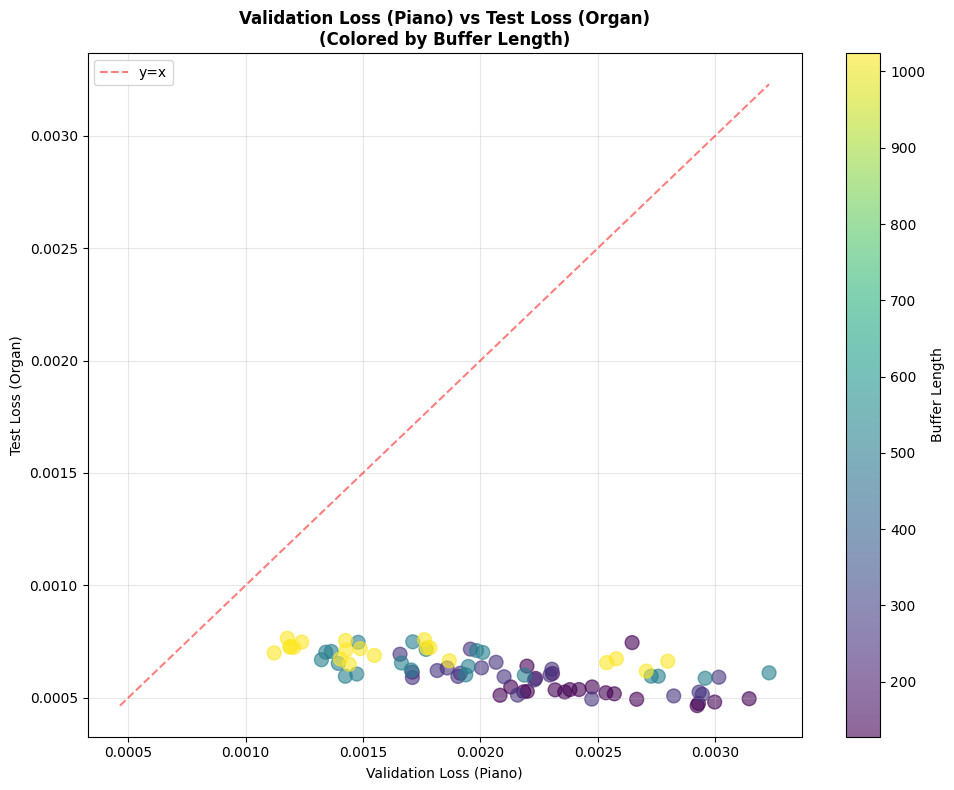

In [7]:
# Create visualizations for different buffer_lengths - Validation Loss (Piano)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# For each buffer_length, create a heatmap for validation loss (piano)
for idx, buffer_length in enumerate(buffer_lengths):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Filter data for this buffer_length
    df_buffer = df[df['buffer_length'] == buffer_length]
    pivot_val_loss = df_buffer.pivot(index='hidden_size', columns='num_layers', values='final_val_loss')
    
    # Create heatmap
    im = ax.imshow(pivot_val_loss.values, aspect='auto', cmap='viridis_r', origin='lower')
    ax.set_title(f'Val Loss (Piano) - Buffer={buffer_length}\n(Input Size = {buffer_length * num_channels})', 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Number of Layers')
    ax.set_ylabel('Hidden Size')
    ax.set_xticks(range(len(num_layers_list)))
    ax.set_xticklabels(num_layers_list)
    ax.set_yticks(range(len(hidden_sizes)))
    ax.set_yticklabels(hidden_sizes)
    plt.colorbar(im, ax=ax, label='Val Loss')

plt.suptitle('Validation Loss (Piano) by Buffer Length', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Create visualizations for different buffer_lengths - Test Loss (Organ)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# For each buffer_length, create a heatmap for test loss (organ)
for idx, buffer_length in enumerate(buffer_lengths):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Filter data for this buffer_length
    df_buffer = df[df['buffer_length'] == buffer_length]
    pivot_test_loss = df_buffer.pivot(index='hidden_size', columns='num_layers', values='test_loss')
    
    # Create heatmap
    im = ax.imshow(pivot_test_loss.values, aspect='auto', cmap='viridis_r', origin='lower')
    ax.set_title(f'Test Loss (Organ) - Buffer={buffer_length}\n(Input Size = {buffer_length * num_channels})', 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Number of Layers')
    ax.set_ylabel('Hidden Size')
    ax.set_xticks(range(len(num_layers_list)))
    ax.set_xticklabels(num_layers_list)
    ax.set_yticks(range(len(hidden_sizes)))
    ax.set_yticklabels(hidden_sizes)
    plt.colorbar(im, ax=ax, label='Test Loss')

plt.suptitle('Test Loss (Organ) by Buffer Length', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Line plots comparing buffer_lengths
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Validation Loss vs Number of Layers (grouped by buffer_length)
for buffer_length in buffer_lengths:
    for hidden_size in hidden_sizes:
        subset = df[(df['buffer_length'] == buffer_length) & 
                    (df['hidden_size'] == hidden_size)].sort_values('num_layers')
        if len(subset) > 0:
            axes[0].plot(subset['num_layers'], subset['final_val_loss'], 
                        marker='o', label=f'b={buffer_length}, h={hidden_size}', 
                        alpha=0.7, linewidth=1.5)
axes[0].set_title('Validation Loss vs Number of Layers\n(All buffer_length × hidden_size combinations)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Layers')
axes[0].set_ylabel('Validation Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot 2: Validation Loss vs Hidden Size (grouped by buffer_length)
for buffer_length in buffer_lengths:
    for num_layers in num_layers_list:
        subset = df[(df['buffer_length'] == buffer_length) & 
                    (df['num_layers'] == num_layers)].sort_values('hidden_size')
        if len(subset) > 0:
            axes[1].plot(subset['hidden_size'], subset['final_val_loss'], 
                        marker='s', label=f'b={buffer_length}, l={num_layers}', 
                        alpha=0.7, linewidth=1.5)
axes[1].set_title('Validation Loss vs Hidden Size\n(All buffer_length × num_layers combinations)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hidden Size')
axes[1].set_ylabel('Validation Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot 3: Validation Loss vs Buffer Length (grouped by hidden_size and num_layers)
for hidden_size in hidden_sizes:
    for num_layers in num_layers_list:
        subset = df[(df['hidden_size'] == hidden_size) & 
                    (df['num_layers'] == num_layers)].sort_values('buffer_length')
        if len(subset) > 0:
            axes[2].plot(subset['buffer_length'], subset['final_val_loss'], 
                        marker='^', label=f'h={hidden_size}, l={num_layers}', 
                        alpha=0.7, linewidth=1.5)
axes[2].set_title('Validation Loss vs Buffer Length\n(All hidden_size × num_layers combinations)', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Buffer Length')
axes[2].set_ylabel('Validation Loss')
axes[2].grid(True, alpha=0.3)
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Scatter plots: Parameters vs Loss (validation and test)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Validation Loss (Piano)
scatter1 = axes[0].scatter(df['num_parameters'], df['final_val_loss'], 
                          c=df['buffer_length'], s=100, 
                          alpha=0.6, cmap='viridis')
axes[0].set_title('Validation Loss (Piano) vs Model Size\n(Colored by Buffer Length)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Parameters (log scale)')
axes[0].set_ylabel('Validation Loss (Piano)')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Buffer Length')

# Test Loss (Organ)
scatter2 = axes[1].scatter(df['num_parameters'], df['test_loss'], 
                          c=df['buffer_length'], s=100, 
                          alpha=0.6, cmap='viridis')
axes[1].set_title('Test Loss (Organ) vs Model Size\n(Colored by Buffer Length)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Parameters (log scale)')
axes[1].set_ylabel('Test Loss (Organ)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Buffer Length')

plt.tight_layout()
plt.show()

# Comparison: Validation Loss (Piano) vs Test Loss (Organ)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(df['final_val_loss'], df['test_loss'], 
          c=df['buffer_length'], s=100, 
          alpha=0.6, cmap='viridis')
ax.set_title('Validation Loss (Piano) vs Test Loss (Organ)\n(Colored by Buffer Length)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Validation Loss (Piano)')
ax.set_ylabel('Test Loss (Organ)')
ax.grid(True, alpha=0.3)
# Add diagonal line for reference
min_loss = min(df['final_val_loss'].min(), df['test_loss'].min())
max_loss = max(df['final_val_loss'].max(), df['test_loss'].max())
ax.plot([min_loss, max_loss], [min_loss, max_loss], 'r--', alpha=0.5, label='y=x')
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Buffer Length')
plt.tight_layout()
plt.show()


## Step 7: Analyze Training Curves

Compare training curves for different configurations to understand convergence behavior.


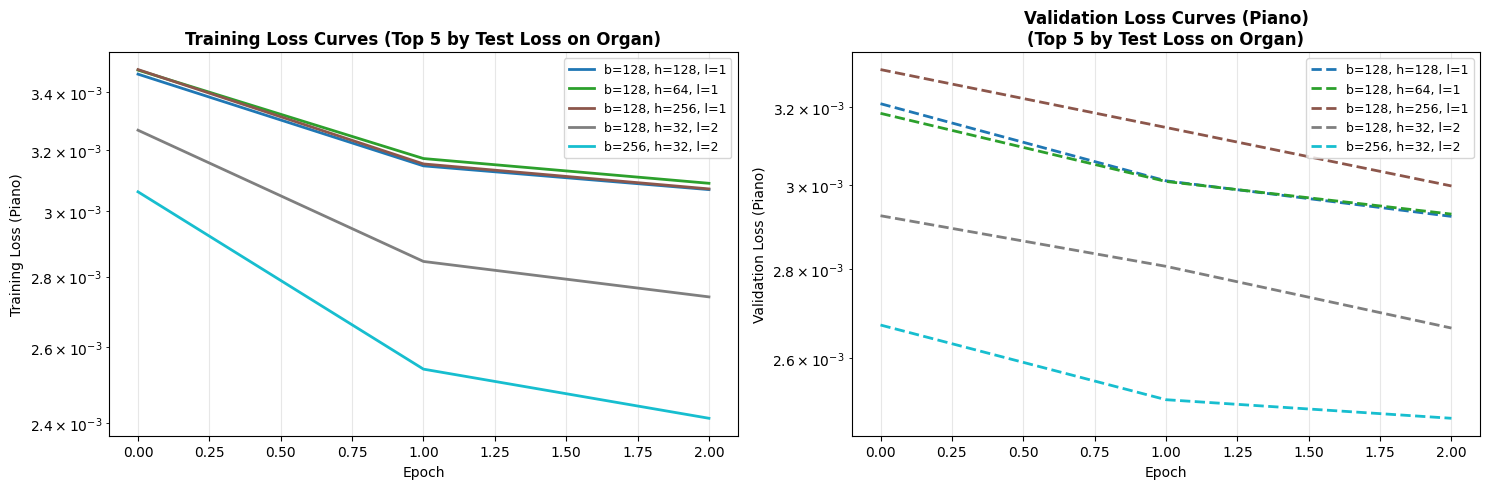

In [8]:
# Plot training curves for selected configurations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Select top 5 configurations by test loss (organ)
top_configs = df_sorted_test.head(5)

colors = plt.cm.tab10(np.linspace(0, 1, len(top_configs)))

for idx, (_, row) in enumerate(top_configs.iterrows()):
    label = f"b={int(row['buffer_length'])}, h={int(row['hidden_size'])}, l={int(row['num_layers'])}"
    axes[0].plot(row['train_losses'], label=label, color=colors[idx], linestyle='-', linewidth=2)
    axes[1].plot(row['val_losses'], label=label, color=colors[idx], linestyle='--', linewidth=2)

axes[0].set_title('Training Loss Curves (Top 5 by Test Loss on Organ)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (Piano)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

axes[1].set_title('Validation Loss Curves (Piano)\n(Top 5 by Test Loss on Organ)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss (Piano)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


## Step 8: Performance vs Model Complexity

Analyze the trade-off between model size (number of parameters) and performance.


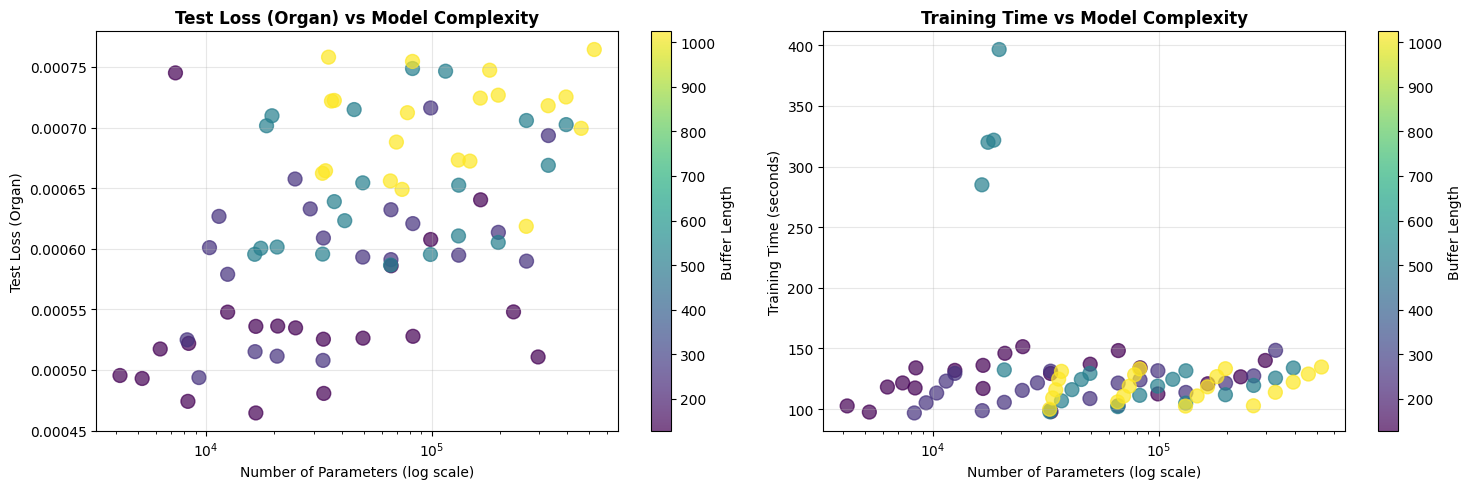


Top 5 most efficient configurations (best test performance per parameter on organ):
 buffer_length  hidden_size  num_layers  num_parameters  test_loss  efficiency_test
           128           32           1            4161   0.000495         0.485106
           128           32           2            5217   0.000493         0.388842
           128           32           3            6273   0.000517         0.308178
           128           64           1            8321   0.000474         0.253500
           256           32           1            8257   0.000525         0.230751

Top 5 most efficient configurations (best validation performance per parameter on piano):
 buffer_length  hidden_size  num_layers  num_parameters  final_val_loss  efficiency_val
           128           32           1            4161        0.003145        0.076413
           128           32           2            5217        0.002666        0.071897
           128           32           3            6273 

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Parameters vs Test Loss (Organ)
scatter = axes[0].scatter(df['num_parameters'], df['test_loss'], 
                         c=df['buffer_length'], s=100, alpha=0.7, cmap='viridis')
axes[0].set_title('Test Loss (Organ) vs Model Complexity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Parameters (log scale)')
axes[0].set_ylabel('Test Loss (Organ)')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Buffer Length')

# Training Time vs Parameters
scatter2 = axes[1].scatter(df['num_parameters'], df['training_time'], 
                          c=df['buffer_length'], s=100, alpha=0.7, cmap='viridis')
axes[1].set_title('Training Time vs Model Complexity', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Parameters (log scale)')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Buffer Length')

plt.tight_layout()
plt.show()

# Efficiency: Best performance per parameter (using test loss on organ)
df['efficiency_val'] = 1 / (df['final_val_loss'] * df['num_parameters'])
df['efficiency_test'] = 1 / (df['test_loss'] * df['num_parameters'])
df_efficiency_test = df.sort_values('efficiency_test', ascending=False)
df_efficiency_val = df.sort_values('efficiency_val', ascending=False)

print("\nTop 5 most efficient configurations (best test performance per parameter on organ):")
print(df_efficiency_test[['buffer_length', 'hidden_size', 'num_layers', 'num_parameters', 
                          'test_loss', 'efficiency_test']].head().to_string(index=False))

print("\nTop 5 most efficient configurations (best validation performance per parameter on piano):")
print(df_efficiency_val[['buffer_length', 'hidden_size', 'num_layers', 'num_parameters', 
                         'final_val_loss', 'efficiency_val']].head().to_string(index=False))


## Step 9: Summary Statistics

Generate summary statistics grouped by each hyperparameter.


In [10]:
print("Summary Statistics by Buffer Length:")
print("=" * 80)
summary_buffer = df.groupby('buffer_length').agg({
    'final_val_loss': ['mean', 'std', 'min', 'max'],
    'test_loss': ['mean', 'std', 'min', 'max'],
    'input_size': 'mean',
    'num_parameters': 'mean',
    'training_time': 'mean'
}).round(6)
print(summary_buffer)
print("\n")

print("Summary Statistics by Hidden Size:")
print("=" * 80)
summary_hidden = df.groupby('hidden_size').agg({
    'final_val_loss': ['mean', 'std', 'min', 'max'],
    'test_loss': ['mean', 'std', 'min', 'max'],
    'num_parameters': 'mean',
    'training_time': 'mean'
}).round(6)
print(summary_hidden)
print("\n")

print("Summary Statistics by Number of Layers:")
print("=" * 80)
summary_layers = df.groupby('num_layers').agg({
    'final_val_loss': ['mean', 'std', 'min', 'max'],
    'test_loss': ['mean', 'std', 'min', 'max'],
    'num_parameters': 'mean',
    'training_time': 'mean'
}).round(6)
print(summary_layers)


Summary Statistics by Buffer Length:
              final_val_loss                               test_loss  \
                        mean       std       min       max      mean   
buffer_length                                                          
128                 0.002485  0.000312  0.002084  0.003145  0.000541   
256                 0.002194  0.000434  0.001658  0.003016  0.000595   
512                 0.001920  0.000577  0.001323  0.003230  0.000653   
1024                0.001683  0.000547  0.001121  0.002798  0.000703   

                                            input_size num_parameters  \
                    std       min       max       mean           mean   
buffer_length                                                           
128            0.000064  0.000465  0.000745      128.0        59361.0   
256            0.000061  0.000494  0.000716      256.0        74721.0   
512            0.000055  0.000587  0.000749      512.0       105441.0   
1024           0.000